# BTNet v4: Weight Transfer — European → American (Correct Experiment)

Both Theorems 1 and 2 of Shorokhov (2024) share the same three parameters:
`w^n` (initial layer weights), `b^n` (initial layer biases), and `W` (conv filter).
The two architectures differ only in the hidden-layer activation: **identity** for
European, **maxout** for American.

This notebook tests the correct transfer experiment:

1. Train `BTNetEuropean` on Black–Scholes prices → obtain learned `(w^n, b^n, W)`.
2. Construct `BTNetAmerican` (analytical `w^i, b^i` already set by the constructor).
3. Copy `(w^n, b^n, W)` from the trained European model — **no further training**.
4. Compare against the purely analytical initialisation (Variant A from v3) and QuantLib.

The question: does training on European prices find a `W` that also improves
American pricing, or is the analytical `W` already optimal?

In [18]:
import numpy as np
import torch
from btnn_bs import (
    BTNetEuropean,
    BTNetAmerican,
    train_BTNet,
    bs_put_price,
    plot_comparison,
    plot_errors,
    plot_training_losses,
    plot_prices_with_quantlib,
    plot_errors_vs_quantlib,
    run_quantlib_benchmark,
    error_stats,
    print_comparison_table,
)

## 1. Market Parameters

In [19]:
S0  = 0.5
t0  = 0.0
T   = 1.0
r   = 0.05
sig = 0.25
n_dim = 9

# Training strikes — uniform sample
rng = np.random.default_rng(42)
K_train = rng.uniform(0.25, 0.75, size=200).astype(np.float32)
prices_train = np.array([bs_put_price(S0, K, T, r, sig) for K in K_train], dtype=np.float32)

# Test strikes — dense grid
K_test = np.linspace(0.25, 0.75, 100, dtype=np.float32)

print(f"n_dim={n_dim}, S0={S0}, T={T}, r={r}, sig={sig}")
print(f"Train samples: {len(K_train)}, Test grid: {len(K_test)}")

n_dim=9, S0=0.5, T=1.0, r=0.05, sig=0.25
Train samples: 200, Test grid: 100


## 2. Train BTNetEuropean on Black–Scholes Prices

We train a `BTNetEuropean` on closed-form BS put prices to obtain data-driven `(w^n, b^n, W)`.
These three tensors will be transferred to the American architecture in the next step.

train_BTNet:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch [100/500], Loss: 0.000000
Epoch [200/500], Loss: 0.000000
Epoch [300/500], Loss: 0.000000
Epoch [400/500], Loss: 0.000000
Epoch [500/500], Loss: 0.000000


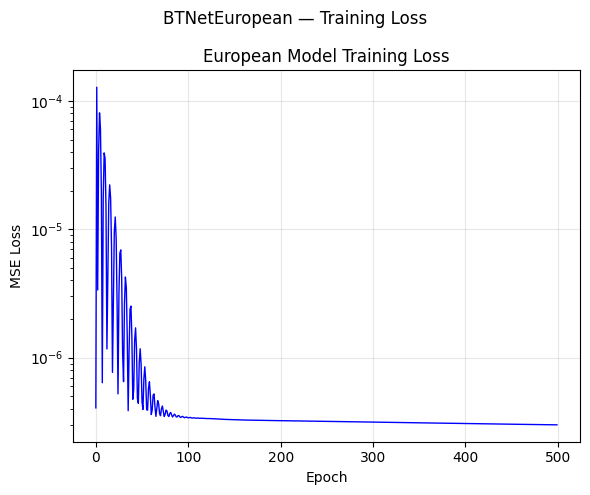

In [20]:
model_european = BTNetEuropean(n_dim, S0, sig, T, t0, r)

loss_hist_euro = train_BTNet(
    model_european,
    K_train,
    prices_train,
    epochs=500,
    lr=0.005,
    log_every=100,
)

plot_training_losses(loss_hist_euro, title="BTNetEuropean — Training Loss")

## 3. Weight Transfer: European → American

Copy the three shared parameters `(w^n, b^n, W)` from the trained European model
into a freshly constructed `BTNetAmerican`.  
The American model retains its own analytical `(w^i, b^i)` per hidden layer — only
the convolutional filter `W` and the initial projection are replaced.  
No further training is performed.

In [21]:
model_amer_transfer = BTNetAmerican(n_dim, S0, sig, T, t0, r)

with torch.no_grad():
    # Transfer w^n, b^n  (initial projection layer)
    model_amer_transfer._initial_layer._linear.weight.data.copy_(
        model_european._initial_layer._linear.weight.data
    )
    model_amer_transfer._initial_layer._linear.bias.data.copy_(
        model_european._initial_layer._linear.bias.data
    )

    # Transfer W (conv filter) into every MaxoutLayer's conv branch
    euro_W = model_european._conv_layer._conv_1d.weight.data  # shape (1, 1, 2)
    for maxout_layer in model_amer_transfer._maxout_layers:
        maxout_layer._conv_1d.weight.data.copy_(euro_W)

# Freeze everything — no training
for p in model_amer_transfer.parameters():
    p.requires_grad_(False)
model_amer_transfer.eval()

print("Transferred W:", euro_W.squeeze().tolist())
print("Parameters frozen:", all(not p.requires_grad for p in model_amer_transfer.parameters()))

Transferred W: [0.4889150559902191, 0.5063319802284241]
Parameters frozen: True


## 4. Baseline: BTNetAmerican with Analytical Weights

This model uses the purely analytical initialisation from Theorem 2 — no training at all.
It serves as the baseline to compare against the weight-transfer variant.

In [22]:
model_amer_analytical = BTNetAmerican(n_dim, S0, sig, T, t0, r)

for p in model_amer_analytical.parameters():
    p.requires_grad_(False)
model_amer_analytical.eval()

analytical_W = model_amer_analytical._maxout_layers[0]._conv_1d.weight.data.squeeze().tolist()
print("Analytical W:", analytical_W)

Analytical W: [0.48473337292671204, 0.5097264647483826]


## 5. QuantLib Reference Prices

QuantLib CRR with 500 steps is our ground truth for American put prices.

In [23]:
ql_result = run_quantlib_benchmark(
    S0, K_test, T, r, sig, amer_crr_steps=500
)
ql_prices = ql_result.ql_american_crr  # numpy array of American CRR put prices

print(f"QuantLib prices computed: {len(ql_prices)} values, "
      f"range [{ql_prices.min():.4f}, {ql_prices.max():.4f}]")

QuantLib prices computed: 100 values, range [0.0000, 0.2500]


## 6. Predictions and Error Comparison

In [24]:
K_test_t = torch.from_numpy(K_test).float().unsqueeze(1)

with torch.no_grad():
    pred_transfer   = model_amer_transfer.predict(K_test_t).flatten()
    pred_analytical = model_amer_analytical.predict(K_test_t).flatten()

stats_transfer   = error_stats(pred_transfer,   ql_prices)
stats_analytical = error_stats(pred_analytical, ql_prices)

print_comparison_table(
    american={
        "Transferred W": stats_transfer,
        "Analytical W":  stats_analytical,
    }
)

American put — errors vs QuantLib (CRR tree)
  Transferred W           MAE=4.38e-04  RMSE=6.81e-04  max|.|=1.71e-03
  Analytical W            MAE=2.84e-04  RMSE=4.06e-04  max|.|=1.10e-03


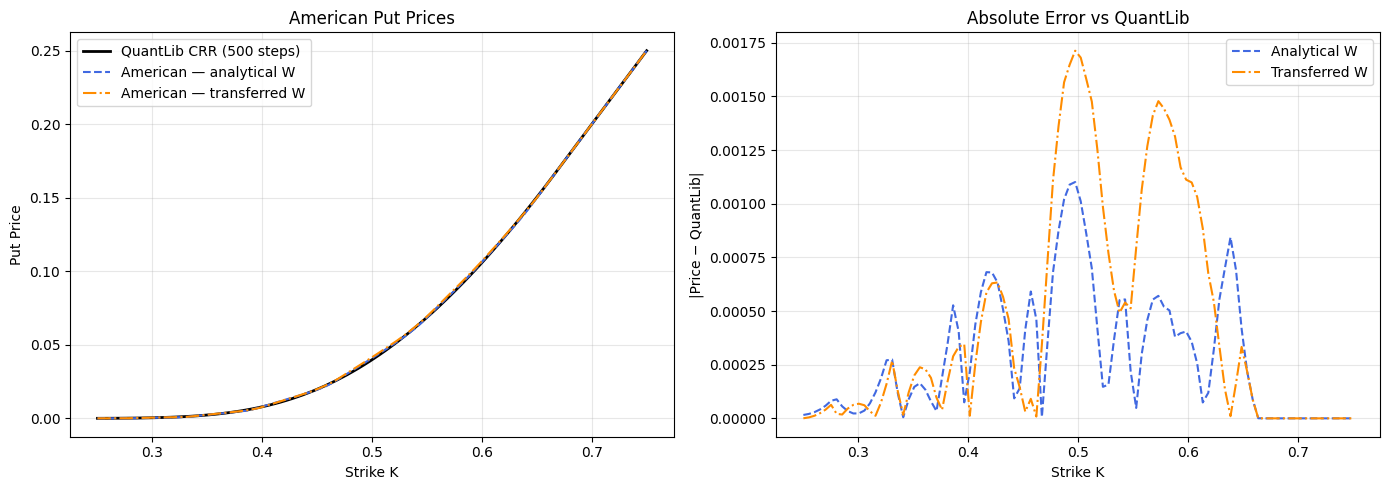

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: price curves
axes[0].plot(K_test, ql_prices,        label="QuantLib CRR (500 steps)", lw=2, color="black")
axes[0].plot(K_test, pred_analytical,  label="American — analytical W",   lw=1.5, linestyle="--", color="royalblue")
axes[0].plot(K_test, pred_transfer,    label="American — transferred W",  lw=1.5, linestyle="-.", color="darkorange")
axes[0].set_xlabel("Strike K")
axes[0].set_ylabel("Put Price")
axes[0].set_title("American Put Prices")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: absolute errors vs QuantLib
err_analytical = np.abs(pred_analytical - ql_prices)
err_transfer   = np.abs(pred_transfer   - ql_prices)

axes[1].plot(K_test, err_analytical, label="Analytical W",  lw=1.5, linestyle="--", color="royalblue")
axes[1].plot(K_test, err_transfer,   label="Transferred W", lw=1.5, linestyle="-.", color="darkorange")
axes[1].set_xlabel("Strike K")
axes[1].set_ylabel("|Price − QuantLib|")
axes[1].set_title("Absolute Error vs QuantLib")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Results and Conclusions

### What the experiment tests

Theorems 1 and 2 of Shorokhov (2024) share exactly three parameters: the initial
projection `(w^n, b^n)` and the convolutional filter `W`.  The two network
architectures differ only in their hidden-layer activations — **identity** for
the European case, **maxout** (continuation vs intrinsic value) for the American
case.  The question: if we train `(w^n, b^n, W)` on European Black–Scholes data,
does the learned filter carry useful information when plugged into the American
architecture — or is the analytical initialisation already optimal?

### Numerical results

| Model | MAE | RMSE | max\|err\| |
|---|---|---|---|
| BTNetAmerican — analytical W | **2.84 × 10⁻⁴** | **4.06 × 10⁻⁴** | **1.10 × 10⁻³** |
| BTNetAmerican — transferred W | 4.38 × 10⁻⁴ | 6.81 × 10⁻⁴ | 1.71 × 10⁻³ |

The convolutional filter values tell the story directly:

- **Analytical W** (Theorem 2): `[0.4847, 0.5097]`
- **Transferred W** (European training): `[0.4889, 0.5063]`

European training nudged `W` away from the analytically correct CRR risk-neutral
probabilities by roughly 0.004 in each component. This small perturbation is enough
to degrade American pricing accuracy by ~55% in MAE.

### Interpretation

The transferred weights are **worse**, not better. This is the key finding.

European training minimises MSE against Black–Scholes put prices. The optimal `W`
for that objective is not the same as the CRR risk-neutral `W` required for exact
American pricing — the two loss surfaces have different minima. When the trained `W`
is inserted into the American maxout layers, every early-exercise comparison at every
node uses a slightly wrong discounting coefficient, and the errors accumulate across
all `n_dim = 9` layers.

### Theoretical grounding

The result is fully consistent with the paper's intent. Theorems 1 and 2 are
**existence** results: they show that exact CRR pricing *can* be represented as a
feedforward network with specific analytical weights. They make no claim that
European training converges to the American optimum, or that the shared-parameter
structure enables useful transfer.

The practical conclusion is unambiguous: **use the analytical initialisation from
Theorem 2 directly**. Training on European data is not only unnecessary — it actively
moves `W` away from the provably correct values and makes American pricing less
accurate.